# CSCI450 Project 2
## **Playing Card Detection**

https://universe.roboflow.com/augmented-startups/playing-cards-ow27d

**Our Team:**

**- Lyudmyla Buhayenko**

**- Sergei Vorobev**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from skimage import io
import os
import json
import warnings
warnings.filterwarnings('ignore')

In [2]:
dataset_dir = '../Playing Cards.v3-original_raw-images.coco'
split_names = ['train', 'valid', 'test']
subsample_dir = '../subsamples'
os.makedirs(subsample_dir, exist_ok=True)

SEED = 42
random.seed(SEED)

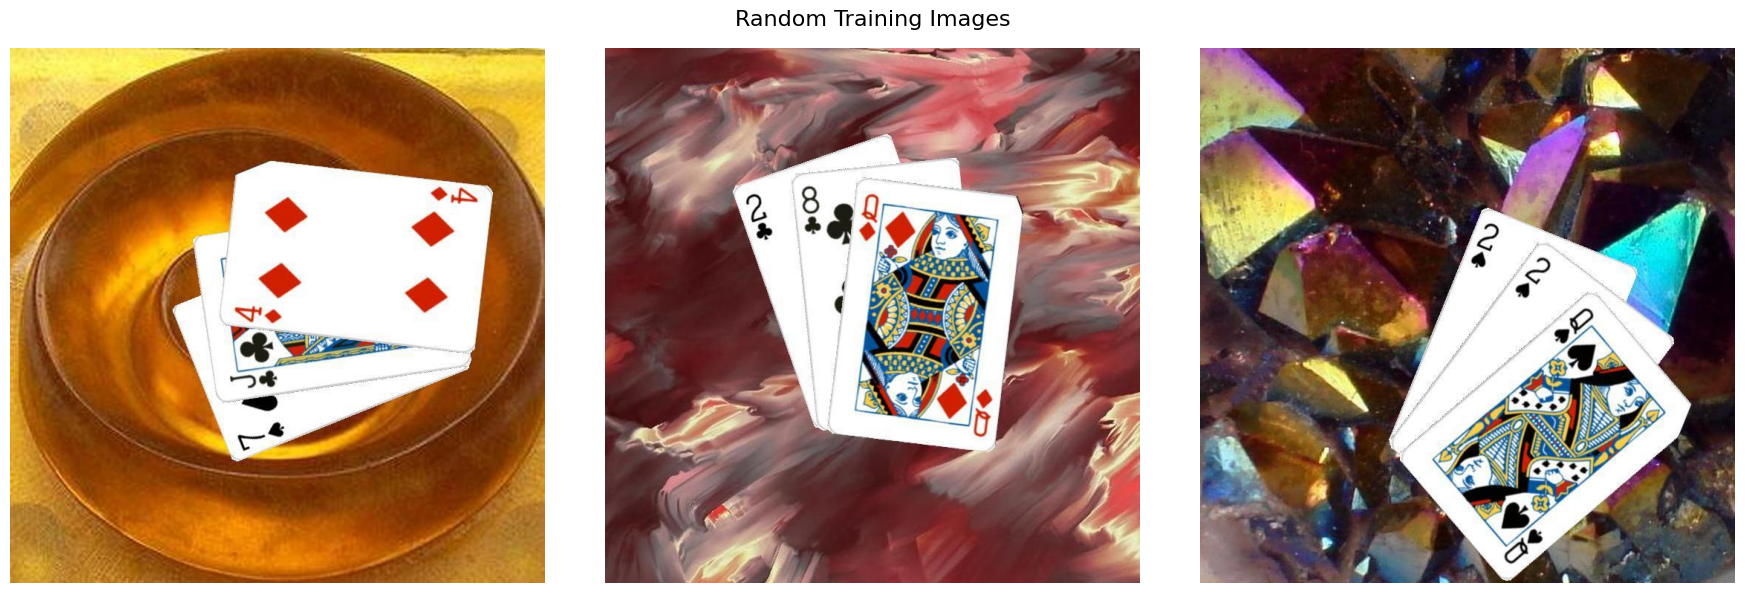

In [3]:
train_dir = os.path.join(dataset_dir, 'train')
images = os.listdir(train_dir)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Random Training Images', fontsize=16)

for i in range(3):
    random_image = random.choice(images)
    img = io.imread(os.path.join(train_dir, random_image))
    axes[i].imshow(img)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Fill out later: Object detection, what is YOLO, don't want to use a pretrained model so use our own approach. Explain the approach.

### Cropped Subsamples Creation

In [4]:
def get_random_background_crop(img, all_anns_for_image, crop_w, crop_h, max_attempts=50):
    img_h, img_w = img.shape[:2]
    for _ in range(max_attempts):
        rx = random.randint(0, img_w - crop_w)
        ry = random.randint(0, img_h - crop_h)

        overlap = False
        for ann in all_anns_for_image:
            ax = int(ann['bbox'][0])
            ay = int(ann['bbox'][1])
            aw = int(ann['bbox'][2])
            ah = int(ann['bbox'][3])
            if not (rx + crop_w < ax or rx > ax + aw or ry + crop_h < ay or ry > ay + ah):
                overlap = True
                break

        if not overlap:
            return img[ry:ry+crop_h, rx:rx+crop_w]
    return None

#### Use dataset annotations to save cropped class images

In [5]:
for split in split_names:
    os.makedirs(os.path.join(subsample_dir, split), exist_ok=True)
    with open(os.path.join(dataset_dir, split, '_annotations.coco.json')) as f:
        data = json.load(f)

    images = {}
    for img in data['images']:
        images[img['id']] = img['file_name']

    categories = {}
    for cat in data['categories']:
        categories[cat['id']] = cat['name']

    annotations_by_image = {}
    for ann in data['annotations']:
        img_id = ann['image_id']
        if img_id not in annotations_by_image:
            annotations_by_image[img_id] = []
        annotations_by_image[img_id].append(ann)

    counter = 0
    bg_counter = 0

    for ann in data['annotations']:
        filename = images[ann['image_id']]
        class_name = categories[ann['category_id']]
        img = io.imread(os.path.join(dataset_dir, split, filename))

        x = int(ann['bbox'][0])
        y = int(ann['bbox'][1])
        w = int(ann['bbox'][2])
        h = int(ann['bbox'][3])

        crop = img[y:y+h, x:x+w]
        class_dir = os.path.join(subsample_dir, split, class_name)
        os.makedirs(class_dir, exist_ok=True)
        io.imsave(os.path.join(class_dir, f'{counter}.jpg'), crop)
        counter += 1

        all_anns_for_image = annotations_by_image[ann['image_id']]
        bg_crop = get_random_background_crop(img, all_anns_for_image, w, h)
        if bg_crop is not None:
            bg_dir = os.path.join(subsample_dir, split, 'background')
            os.makedirs(bg_dir, exist_ok=True)
            io.imsave(os.path.join(bg_dir, f'{bg_counter}.jpg'), bg_crop)
            bg_counter += 1

    print(f'{split}: saved {counter} card crops and {bg_counter} background crops')

train: saved 28280 card crops and 28280 background crops
valid: saved 8080 card crops and 8080 background crops
test: saved 4040 card crops and 4040 background crops


#### Limit the size of the negative class

In [6]:
for split in split_names:
    split_path = os.path.join(subsample_dir, split)
    
    class_counts = {}
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))
    
    non_bg_counts = []
    for cls, count in class_counts.items():
        if cls != 'background':
            non_bg_counts.append(count)
    
    avg = int(sum(non_bg_counts) / len(non_bg_counts))
    cap = avg * 5
    
    print(f"{split}: average class size={avg}, background cap={cap}, current background={class_counts['background']}")
    
    bg_path = os.path.join(split_path, 'background')
    bg_files = sorted(os.listdir(bg_path))
    if len(bg_files) > cap:
        to_delete = random.sample(bg_files, len(bg_files) - cap)
        for f in to_delete:
            os.remove(os.path.join(bg_path, f))
        print(f"{split}: trimmed background from {len(bg_files)} to {cap}")
    else:
        print(f"{split}: background already under cap")

train: average class size=543, background cap=2715, current background=28280
train: trimmed background from 28280 to 2715
valid: average class size=155, background cap=775, current background=8080
valid: trimmed background from 8080 to 775
test: average class size=77, background cap=385, current background=4040
test: trimmed background from 4040 to 385


#### Class Distribution

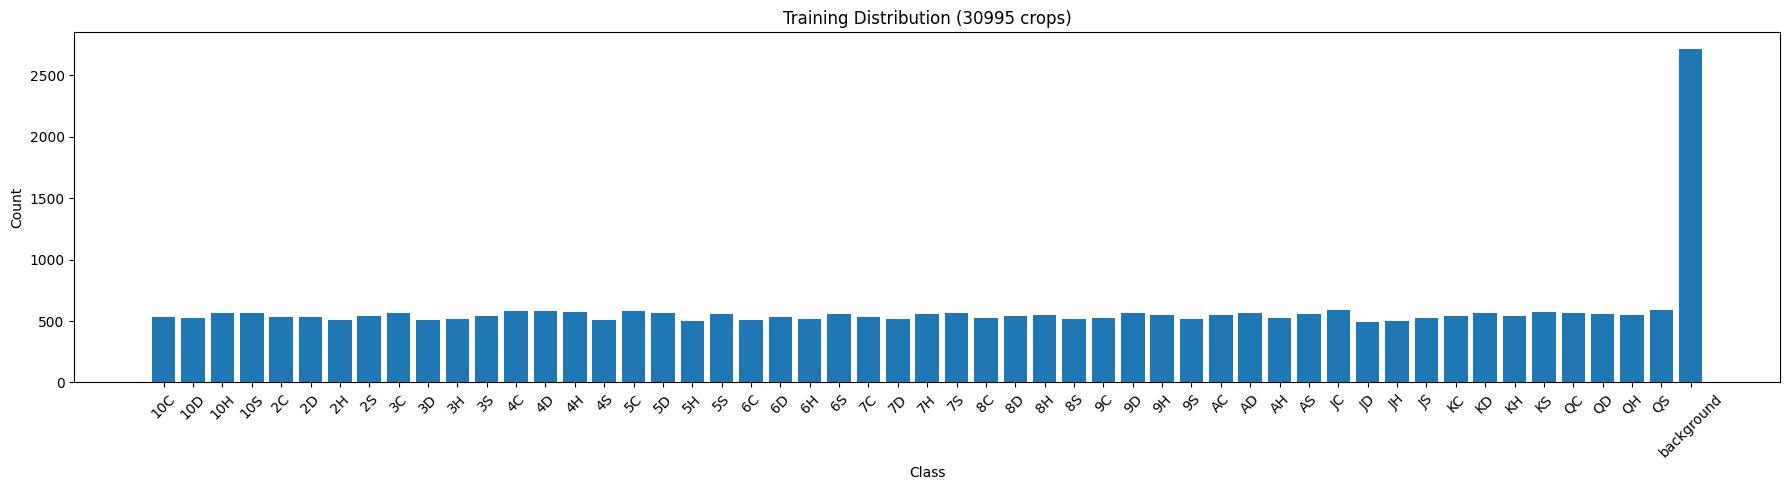

In [7]:
split_path = os.path.join(subsample_dir, 'train')

class_counts = {}
for class_name in sorted(os.listdir(split_path)):
    class_path = os.path.join(split_path, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

plt.figure(figsize=(18, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title(f'Training Distribution ({sum(class_counts.values())} crops)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

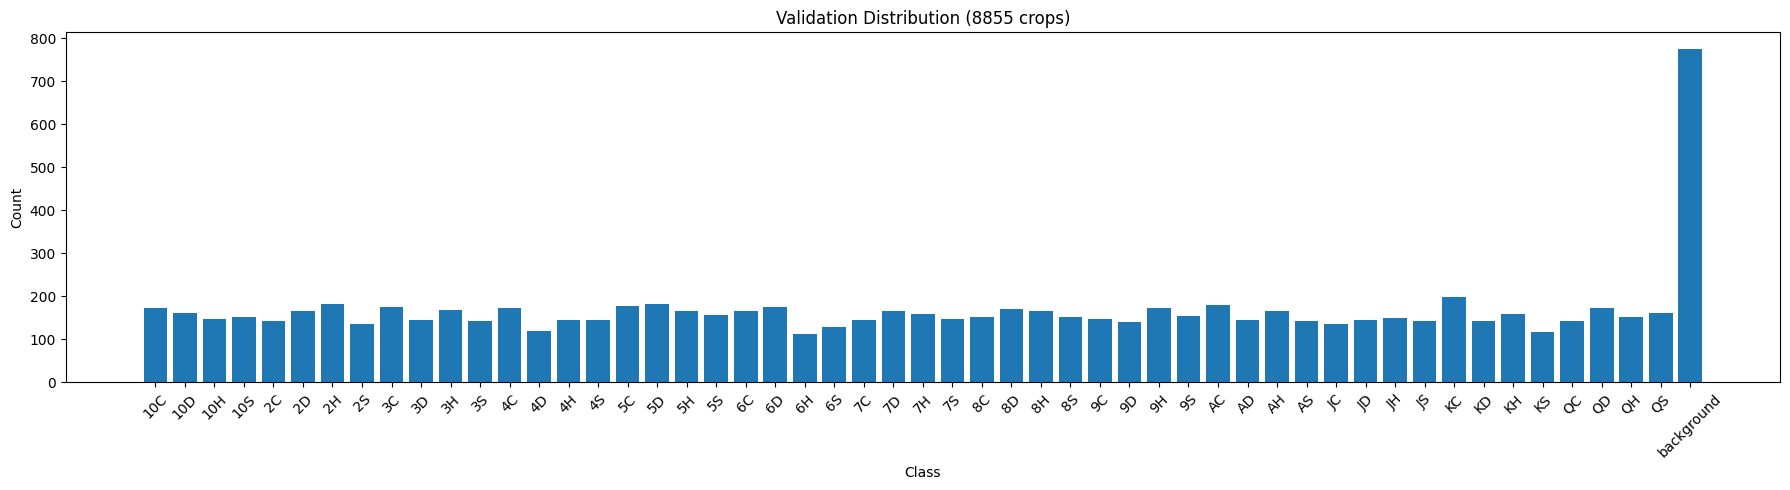

In [8]:
split_path = os.path.join(subsample_dir, 'valid')

class_counts = {}
for class_name in sorted(os.listdir(split_path)):
    class_path = os.path.join(split_path, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

plt.figure(figsize=(18, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title(f'Validation Distribution ({sum(class_counts.values())} crops)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

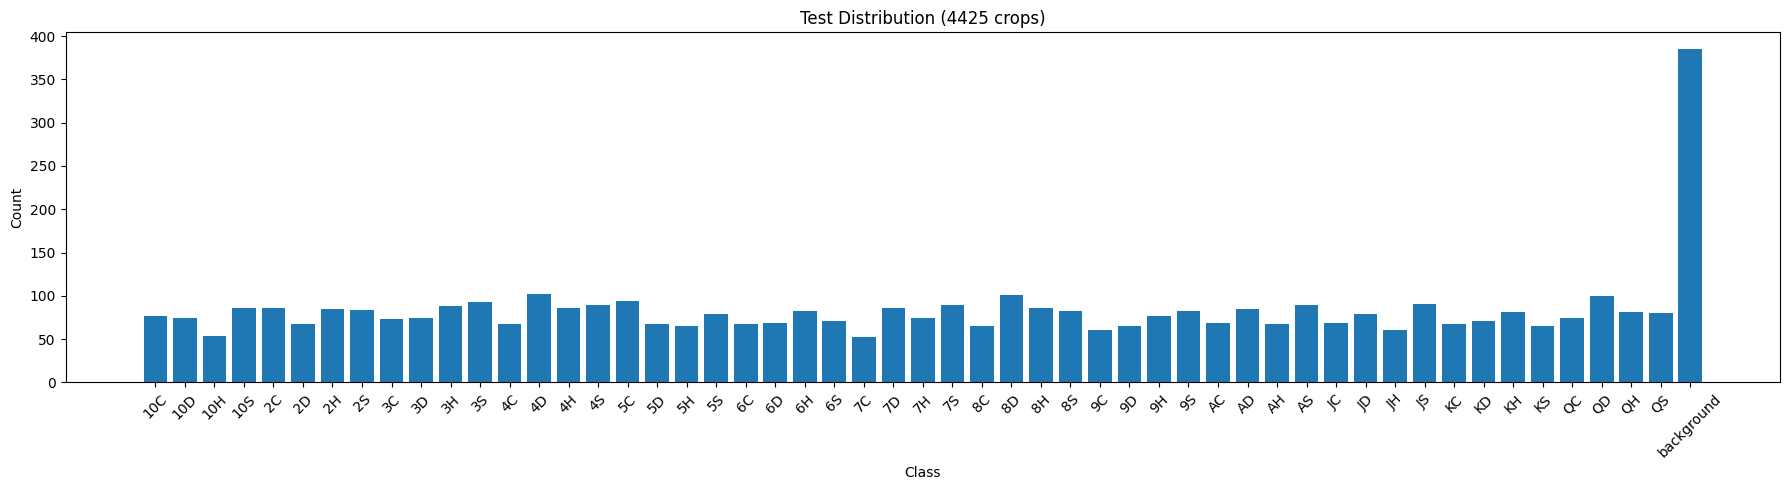

In [9]:
split_path = os.path.join(subsample_dir, 'test')

class_counts = {}
for class_name in sorted(os.listdir(split_path)):
    class_path = os.path.join(split_path, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

plt.figure(figsize=(18, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title(f'Test Distribution ({sum(class_counts.values())} crops)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### CNN Classification Model

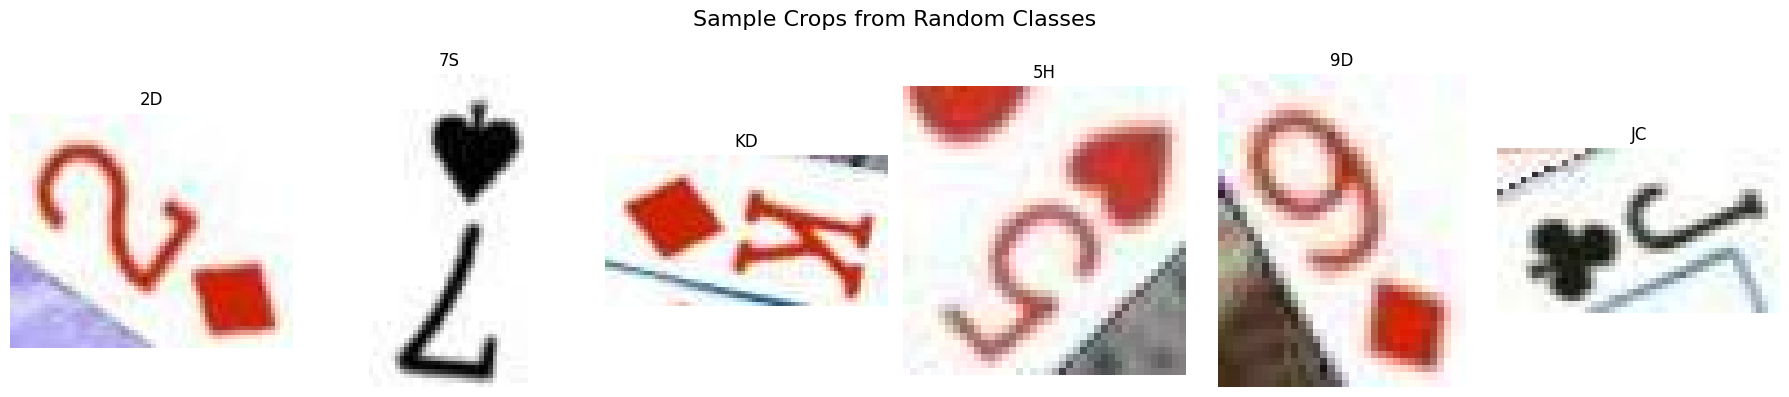

In [10]:
split_path = os.path.join(subsample_dir, 'train')
classes = sorted(os.listdir(split_path))
sample_classes = random.sample(classes, 6)

fig, axes = plt.subplots(1, 6, figsize=(18, 4))
fig.suptitle('Sample Crops from Random Classes', fontsize=16)

for i in range(6):
    class_path = os.path.join(split_path, sample_classes[i])
    sample_file = random.choice(os.listdir(class_path))
    img = io.imread(os.path.join(class_path, sample_file))
    axes[i].imshow(img)
    axes[i].set_title(sample_classes[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [11]:
dataset_dir = '../Playing Cards.v3-original_raw-images.coco'
widths = []
heights = []

for split in split_names:
    with open(os.path.join(dataset_dir, split, '_annotations.coco.json')) as f:
        data = json.load(f)

    for ann in data['annotations']:
        w = int(ann['bbox'][2])
        h = int(ann['bbox'][3])
        widths.append(w)
        heights.append(h)

print(f"Width --- min: {min(widths)}, max: {max(widths)}, avg: {int(sum(widths)/len(widths))}")
print(f"Height --- min: {min(heights)}, max: {max(heights)}, avg: {int(sum(heights)/len(heights))}")

Width --- min: 19, max: 83, avg: 46
Height --- min: 19, max: 83, avg: 46


#### PyTorch CNN Definition

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

print(torch.cuda.is_available())
print(torch.version.cuda)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

False
None
Using device: cpu


In [13]:
temp_dataset = ImageFolder(root='../subsamples/train', transform=transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
]))
temp_loader = DataLoader(temp_dataset, batch_size=64, shuffle=False, num_workers=8)

mean = torch.zeros(3)
std  = torch.zeros(3)
for images, _ in temp_loader:
    mean += images.mean(dim=[0, 2, 3])
    std  += images.std(dim=[0, 2, 3])
mean /= len(temp_loader)
std  /= len(temp_loader)
print(f"Dataset Mean: {mean}, Std: {std}")

train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

val_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

train_dataset = ImageFolder(root='../subsamples/train', transform=train_transforms)
val_dataset   = ImageFolder(root='../subsamples/valid', transform=val_transforms)
test_dataset  = ImageFolder(root='../subsamples/test',  transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,  num_workers=8, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

NUM_CLASSES = len(train_dataset.classes)
print(f"Classes: {NUM_CLASSES}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Dataset Mean: tensor([0.8078, 0.7481, 0.7304]), Std: tensor([0.2434, 0.3041, 0.3157])
Classes: 53
Train: 30995 | Val: 8855 | Test: 4425


In [14]:
class CardCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

        self.loss = nn.CrossEntropyLoss()

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

    def loss_fn(self, y_hat, y):
        return self.loss(y_hat, y)

model = CardCNN(num_classes=NUM_CLASSES).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=3e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
print(model)

CardCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.25, inplace=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout2d(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=53, bias=True)
  )
  (loss): CrossEntropyLoss()
)


#### Model Training

In [15]:
import time

num_epochs = 50
train_loss, val_loss = [], []
train_acc, val_acc   = [], []

start = time.time()

for epoch in range(1, num_epochs + 1):
    model.train()
    ep_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = model.loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        ep_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)

    train_loss.append(ep_loss / len(train_loader))
    train_acc.append(correct / total)

    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            v_loss    += model.loss_fn(outputs, labels).item()
            v_correct += (outputs.argmax(1) == labels).sum().item()
            v_total   += labels.size(0)

    val_loss.append(v_loss / len(val_loader))
    val_acc.append(v_correct / v_total)

    scheduler.step(val_loss[-1])

    print(f"Ep {epoch:02}/{num_epochs} "
          f"| Train L {train_loss[-1]:.4f} A {train_acc[-1]:.3f} "
          f"|| Val L {val_loss[-1]:.4f} A {val_acc[-1]:.3f} "
          f"|| LR {scheduler.get_last_lr()[0]:.6f}")

end = time.time()
print(f"Training time: {end - start:.2f} seconds")
torch.save(model.state_dict(), "card_cnn.pth")
print("Model saved.")

Ep 01/50 | Train L 3.7173 A 0.097 || Val L 3.2981 A 0.147 || LR 0.000100
Ep 02/50 | Train L 3.2180 A 0.143 || Val L 2.8331 A 0.241 || LR 0.000100
Ep 03/50 | Train L 2.8153 A 0.209 || Val L 2.2726 A 0.353 || LR 0.000100
Ep 04/50 | Train L 2.3923 A 0.291 || Val L 1.7037 A 0.533 || LR 0.000100
Ep 05/50 | Train L 1.9982 A 0.379 || Val L 1.2619 A 0.642 || LR 0.000100
Ep 06/50 | Train L 1.6608 A 0.465 || Val L 0.9156 A 0.766 || LR 0.000100
Ep 07/50 | Train L 1.3778 A 0.543 || Val L 0.6602 A 0.836 || LR 0.000100
Ep 08/50 | Train L 1.1579 A 0.609 || Val L 0.4825 A 0.880 || LR 0.000100
Ep 09/50 | Train L 0.9731 A 0.664 || Val L 0.3602 A 0.915 || LR 0.000100
Ep 10/50 | Train L 0.8195 A 0.717 || Val L 0.2753 A 0.938 || LR 0.000100
Ep 11/50 | Train L 0.7163 A 0.753 || Val L 0.2177 A 0.953 || LR 0.000100
Ep 12/50 | Train L 0.6272 A 0.787 || Val L 0.1741 A 0.966 || LR 0.000100
Ep 13/50 | Train L 0.5469 A 0.809 || Val L 0.1347 A 0.975 || LR 0.000100
Ep 14/50 | Train L 0.4850 A 0.833 || Val L 0.1130 A

#### Model Evaluation

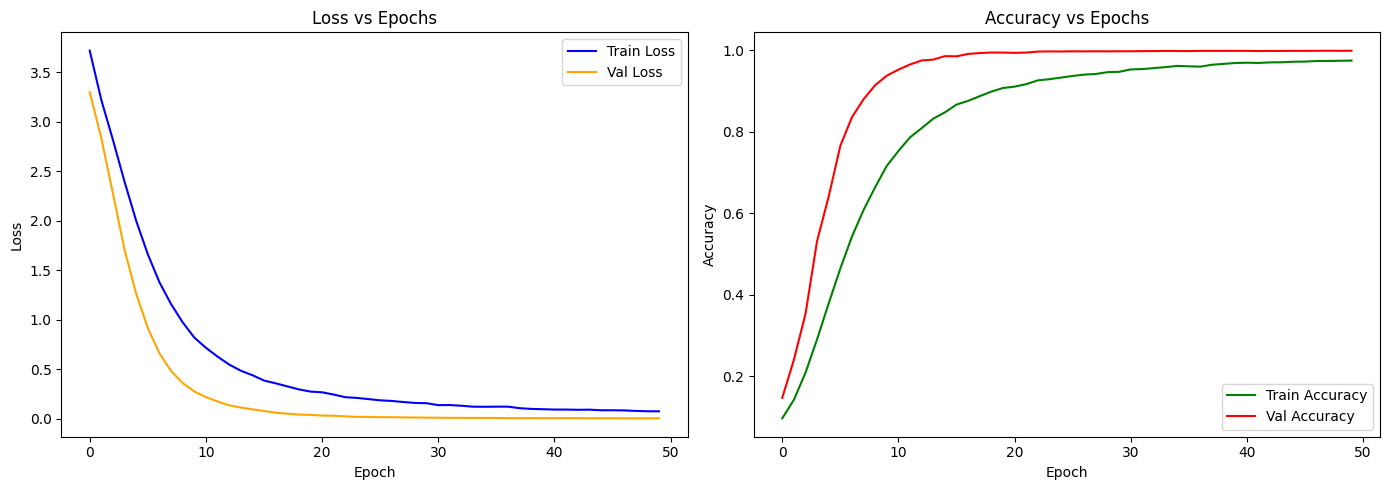

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_loss, label='Train Loss', color='blue')
axes[0].plot(val_loss,   label='Val Loss',   color='orange')
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(train_acc, label='Train Accuracy', color='green')
axes[1].plot(val_acc,   label='Val Accuracy',   color='red')
axes[1].set_title('Accuracy vs Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

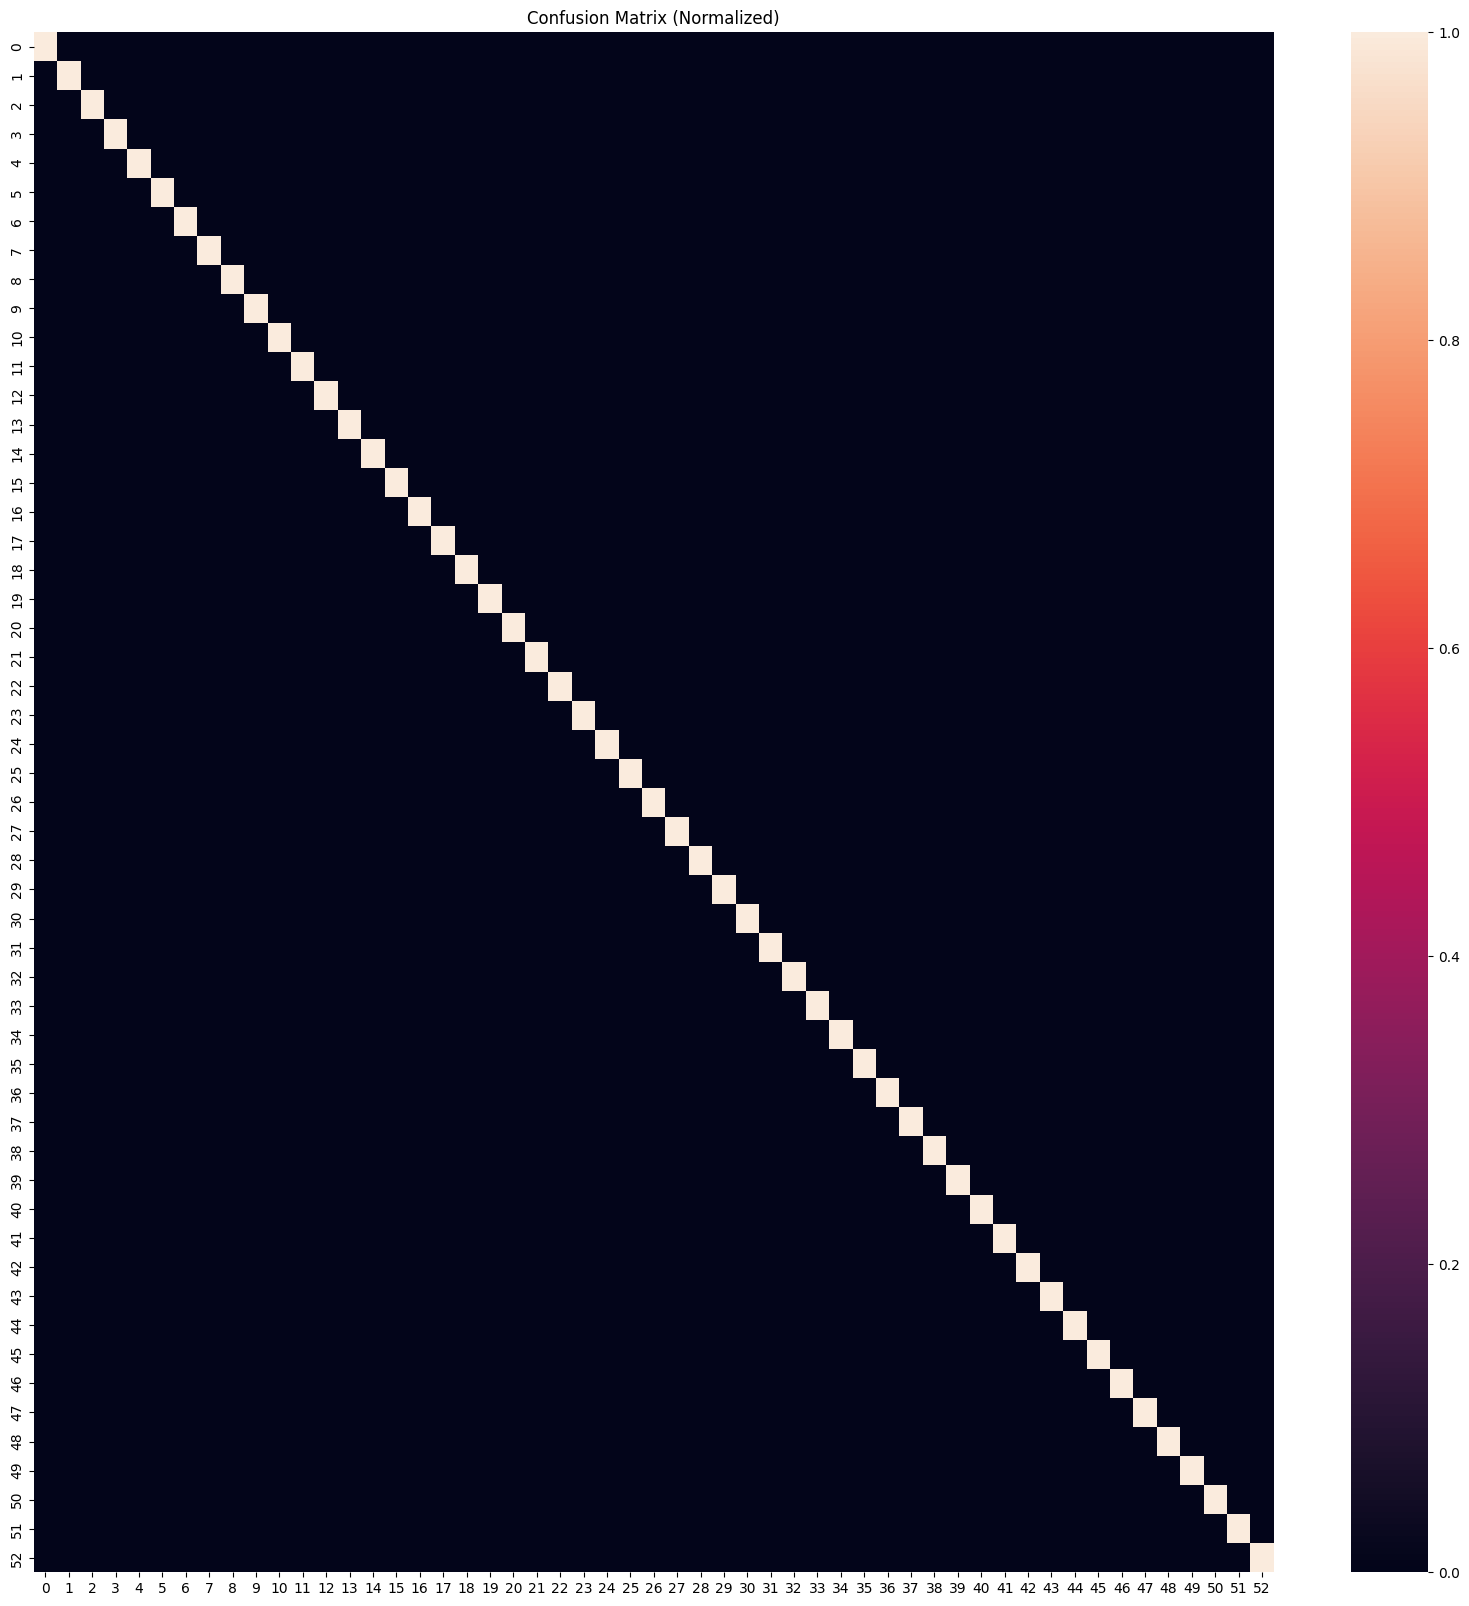

Correct predictions: 4424 / 4425
Test Accuracy: 0.9998


In [17]:
import seaborn as sn

model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        predictions.append(outputs.cpu().numpy())
        true_labels.append(labels.numpy())

predictions = np.concatenate(predictions, axis=0)
true_labels = np.concatenate(true_labels, axis=0)

order = np.argsort(predictions)
conf = np.zeros([NUM_CLASSES, NUM_CLASSES])
count = 0
classcounts = np.zeros(NUM_CLASSES)

for i in range(predictions.shape[0]):
    index = order[i, :]
    index = index[::-1]
    conf[true_labels[i], index[0]] += 1
    classcounts[true_labels[i]] += 1
    if true_labels[i] == index[0]:
        count += 1

conf2 = np.copy(conf)
for i in range(conf2.shape[0]):
    conf2[i, :] /= classcounts[i]

plt.figure(figsize=(20, 20))
sn.heatmap(conf2, vmin=0, vmax=1)
plt.title('Confusion Matrix (Normalized)')
plt.show()

print(f"Correct predictions: {count} / {predictions.shape[0]}")
print(f"Test Accuracy: {count / predictions.shape[0]:.4f}")

### Card Detection

In [18]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CardCNN(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load("card_cnn.pth", map_location=device))
model.eval()
print(f"Model loaded on {device}")

Model loaded on cpu


In [19]:
import matplotlib.patches as patches
from scipy.ndimage import maximum_filter
from PIL import Image

window_size = 64
stride = 16
conf_threshold = 0.6

test_dir = "../Playing Cards.v3-original_raw-images.coco/test"

classes = train_dataset.classes
background_idx = classes.index("background") if "background" in classes else -1


def get_random_image():
    images = [f for f in os.listdir(test_dir) if f.endswith(".jpg")]
    return os.path.join(test_dir, random.choice(images))

In [20]:
#scan image and store confidence scores
def build_heatmap(img, model, device):
    h, w = img.shape[:2]
    heatmap = np.zeros((h // stride, w // stride))
    positions = []

    #slide window across image
    for y in range(0, h - window_size, stride):
        for x in range(0, w - window_size, stride):

            patch = img[y:y+window_size, x:x+window_size]
            patch = Image.fromarray(patch)
            patch = val_transforms(patch).unsqueeze(0).to(device)

            with torch.no_grad():
                out = model(patch)
                prob = torch.softmax(out, dim=1) #convert to probability
                conf, pred = torch.max(prob, 1) #get top class and prediction

            conf = conf.item()
            pred = pred.item()

            if pred != background_idx:
                heatmap[y // stride, x // stride] = max(heatmap[y // stride, x // stride], conf)

            #store position and prediction
            positions.append((x, y, conf, pred))

    return heatmap, positions

In [21]:
#find strong responses and classify them
def extract_peaks(heatmap, threshold=0.85):
    filtered = maximum_filter(heatmap, size=3)
    peaks = (heatmap == filtered) & (heatmap > threshold)
    return np.argwhere(peaks)


def classify_peaks(img, peaks, model, device):
    results = []

    for py, px in peaks:

        x = px * stride
        y = py * stride

        patch = img[y:y+window_size, x:x+window_size]
        patch = Image.fromarray(patch)
        patch = val_transforms(patch).unsqueeze(0).to(device)

        with torch.no_grad():
            out = model(patch)
            prob = torch.softmax(out, dim=1)
            conf, pred = torch.max(prob, 1)

        results.append((x, y, x+window_size, y+window_size, conf.item(), classes[pred.item()]))

    return results

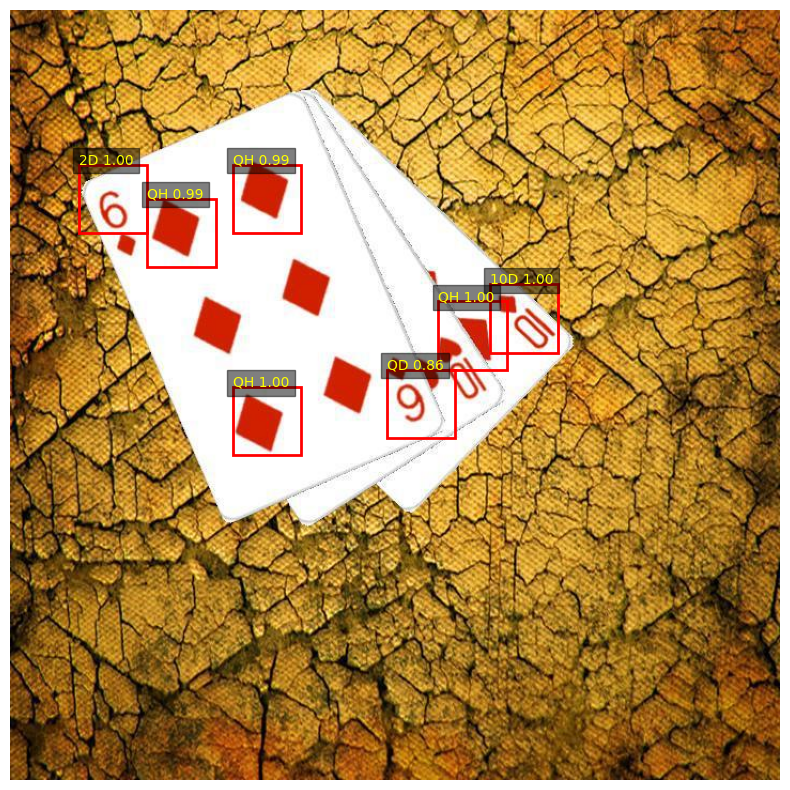

In [37]:
#draw bounding boxes 
def visualize(img, detections):
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img)

    for x1, y1, x2, y2, conf, label in detections:
        ax.add_patch(
            patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )
        )

        ax.text(
            x1,
            y1,
            f"{label} {conf:.2f}",
            color="yellow",
            bbox=dict(facecolor="black", alpha=0.5)
        )

    plt.axis("off")
    plt.show()


image_path = get_random_image()
img = io.imread(image_path)

heatmap, _ = build_heatmap(img, model, device)
peaks = extract_peaks(heatmap)
detections = classify_peaks(img, peaks, model, device)

visualize(img, detections)